# 🍹 Customer Segmentation — Clustering Data Penjualan Minuman

**Submission Machine Learning — Unsupervised Learning (Clustering)**

Notebook ini membangun model **clustering (K-Means)** untuk mengelompokkan data transaksi penjualan minuman (*Synthetic Beverage Sales Data*) ke dalam beberapa segmen berdasarkan pola pembelian, tanpa menggunakan label kelas apa pun.

> 💡 **Cara pakai:** Jalankan seluruh cell secara berurutan dari atas ke bawah (`Runtime > Run all` di Colab, atau `Kernel > Restart & Run All` di Jupyter).

---

## 📑 Daftar Isi

1. [Perkenalan Dataset](#section-1)
2. [Import Library](#section-2)
3. [Memuat Dataset](#section-3)
4. [Exploratory Data Analysis (EDA)](#section-4)
5. [Data Preprocessing](#section-5)
6. [Pembangunan Model Clustering](#section-6)
   - 6a. [Pembangunan Model](#section-6a)
   - 6b. [Evaluasi Model](#section-6b)
   - 6c. [Feature Selection (Opsional)](#section-6c)
   - 6d. [Visualisasi Hasil Clustering](#section-6d)
   - 6e. [Analisis & Interpretasi Cluster](#section-6e)
7. [Mengeksport Data](#section-7)

---

<a id="section-1"></a>
# 1. 📊 Perkenalan Dataset

Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

2. **Ketentuan Dataset**
   - **Tanpa label**: dataset tidak boleh memiliki label atau kelas.
   - **Jumlah baris**: minimal 1.000 baris agar analisis cukup bermakna.
   - **Tipe data**: harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal* → misalnya jenis kelamin, kategori produk.
     - *Numerikal* → misalnya usia, pendapatan, harga.

3. **Pembatasan**  
   Dataset yang sudah biasa dipakai dalam latihan clustering (seperti *customer segmentation* generik) tidak boleh digunakan.

> 📦 **Dataset yang digunakan:** `synthetic_beverage_sales_data.csv` — data transaksi penjualan minuman yang berisi informasi produk, kategori, harga, kuantitas, wilayah, dan tipe pelanggan.

<a id="section-2"></a>
# 2. 📦 Import Library

Pada tahap ini, kita mengimpor seluruh *library* Python yang dibutuhkan untuk manipulasi data, visualisasi, preprocessing, dan pembangunan model clustering.

In [1]:
# --- Manipulasi & analisis data ---
import pandas as pd
import numpy as np

# --- Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- Model & evaluasi clustering ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.cluster import KElbowVisualizer

# --- Pengaturan tampilan visualisasi agar konsisten di seluruh notebook ---
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

# Warna aksen yang dipakai berulang untuk grafik "highlight"
ACCENT_COLOR = "#72BCD4"
MUTED_COLOR = "#D3D3D3"

<a id="section-3"></a>
# 3. 📂 Memuat Dataset

Pada tahap ini, dataset dimuat ke dalam notebook menggunakan `pandas`. Setelah dataset berhasil dimuat, kita mengecek beberapa baris awal dan akhir untuk memahami strukturnya serta memastikan data sudah terbaca dengan benar.

> ⚠️ **Catatan:** sesuaikan variabel `path` di bawah ini dengan lokasi file dataset pada perangkat/environment Anda (misalnya path lokal, atau path Google Drive jika dijalankan di Colab).

In [2]:
# Membaca dataset dari file CSV
path = "D:/7. PROYEK/3. BEVERAGE SALES/Clustering_Classification/1. Dataset/synthetic_beverage_sales_data.csv"
df = pd.read_csv(path)

print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset: 50000 baris, 11 kolom


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


**5 baris terakhir dataset:**

In [3]:
df.tail()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
49995,ORD16765,CUS6053,B2C,Cranberry Juice,Juices,3.67,2,0.0,7.34,Hessen,2023-06-15
49996,ORD16765,CUS6053,B2C,Passion Fruit Juice,Juices,3.11,12,0.0,37.32,Hessen,2023-06-15
49997,ORD16765,CUS6053,B2C,Apollinaris,Water,0.99,8,0.0,7.92,Hessen,2023-06-15
49998,ORD16766,CUS1880,B2C,Riesling,Alcoholic Beverages,4.07,11,0.0,44.77,Rheinland-Pfalz,2021-05-12
49999,ORD16766,CUS1880,B2C,Selters,Water,0.46,9,0.0,4.14,Rheinland-Pfalz,2021-05-12


<a id="section-4"></a>
# 4. 🔍 Exploratory Data Analysis (EDA)

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami struktur data**
   - Tinjau jumlah baris dan kolom dalam dataset.
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani data yang hilang**
   - Identifikasi dan analisis *missing values*, lalu tentukan langkah penanganannya (imputasi atau penghapusan).

3. **Analisis distribusi dan korelasi**
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi (histogram, boxplot).
   - Periksa hubungan antar variabel menggunakan matriks korelasi.

4. **Visualisasi data**
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah memperoleh wawasan awal yang mendalam mengenai data sebelum masuk ke tahap *preprocessing* dan *modeling*.

## 4.1 Informasi Umum & Kualitas Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       50000 non-null  object 
 1   Customer_ID    50000 non-null  object 
 2   Customer_Type  50000 non-null  object 
 3   Product        50000 non-null  object 
 4   Category       50000 non-null  object 
 5   Unit_Price     50000 non-null  float64
 6   Quantity       50000 non-null  int64  
 7   Discount       50000 non-null  float64
 8   Total_Price    50000 non-null  float64
 9   Region         50000 non-null  object 
 10  Order_Date     50000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 4.2+ MB


**Statistik deskriptif** untuk seluruh kolom (numerik & kategorikal):

In [5]:
df.describe(include='all').round(2)

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
count,50000,50000,50000,50000,50000,50000.00,50000.00,50000.00,50000.00,50000,50000
unique,16766,8157,2,47,4,NaN,NaN,NaN,NaN,16,1094
top,ORD12,CUS4566,B2C,Mango Juice,Soft Drinks,NaN,NaN,NaN,NaN,Bremen,2021-06-16
freq,5,33,32160,1837,12562,NaN,NaN,NaN,NaN,3334,89
mean,NaN,NaN,NaN,NaN,NaN,5.75,23.12,0.03,128.72,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.58,26.87,0.04,503.69,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.32,1.00,0.00,0.38,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.06,6.00,0.00,8.48,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.75,11.00,0.00,21.14,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3.21,30.00,0.05,69.00,NaN,NaN


**Pengecekan missing values** per kolom:

In [6]:
df.isnull().sum()

Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
dtype: int64

**Pengecekan data duplikat:**

In [7]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data terduplikat: {jumlah_duplikat}")

Jumlah data terduplikat: 0


## 4.2 Pengelompokan Tipe Fitur

Memisahkan kolom berdasarkan tipe data agar mempermudah analisis dan preprocessing selanjutnya.

In [8]:
numeric_features = df.select_dtypes(include=["number"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns
integer_features = df.select_dtypes(include=["int64"]).columns
float_features = df.select_dtypes(include=["float64"]).columns
int_float_features = df.select_dtypes(include=["int64", "float64"]).columns

print("Fitur numerik   :", list(numeric_features))
print("Fitur kategorikal:", list(categorical_features))

Fitur numerik   : ['Unit_Price', 'Quantity', 'Discount', 'Total_Price']
Fitur kategorikal: ['Order_ID', 'Customer_ID', 'Customer_Type', 'Product', 'Category', 'Region', 'Order_Date']


## 4.3 Deteksi Outlier (Boxplot)

Boxplot digunakan untuk melihat sebaran nilai serta mengidentifikasi potensi outlier pada tiap fitur numerik.

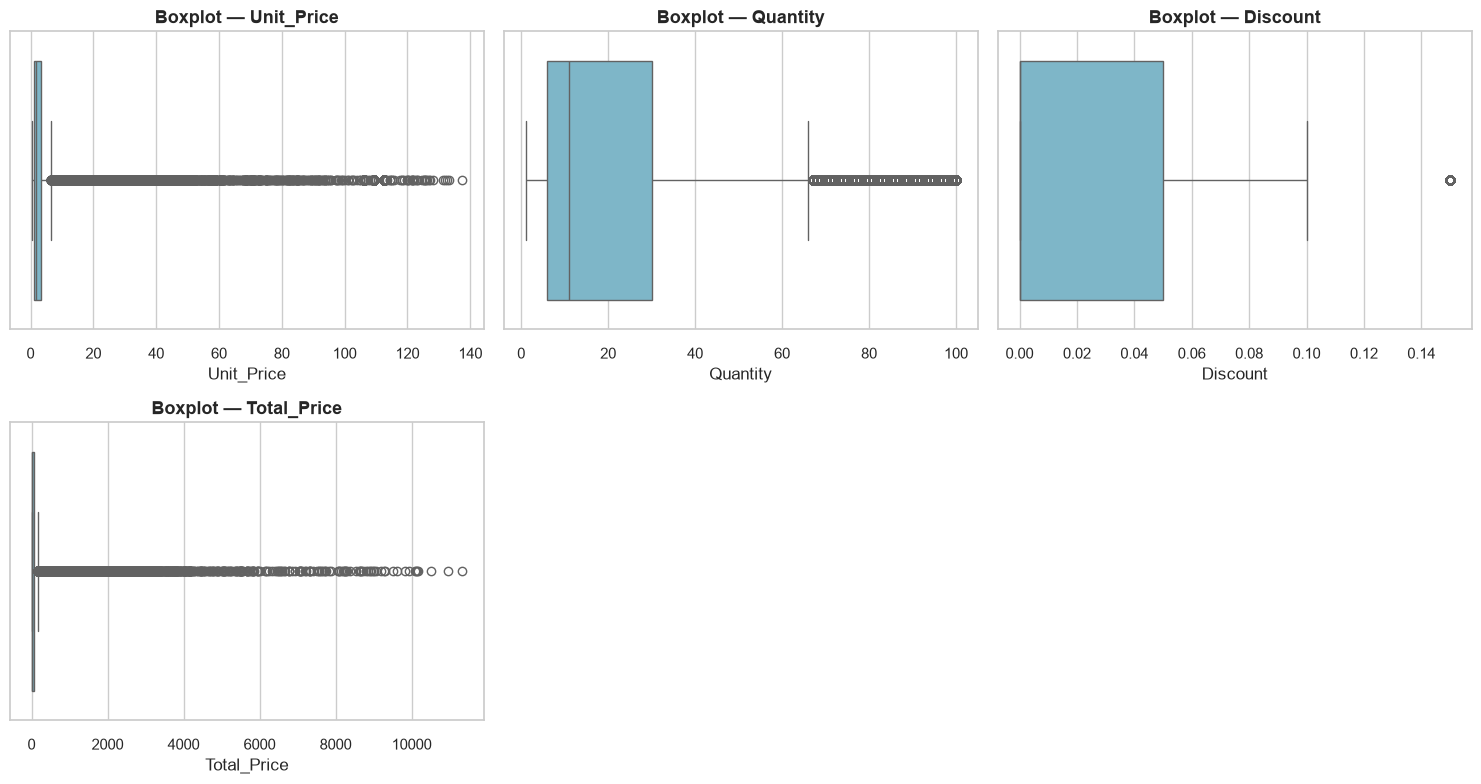

In [9]:
n_cols = 3
n_rows = -(-len(numeric_features) // n_cols)  # pembulatan ke atas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x=df[feature], ax=axes[i], color=ACCENT_COLOR)
    axes[i].set_title(f"Boxplot — {feature}")

# Sembunyikan subplot kosong (jika jumlah fitur tidak habis dibagi n_cols)
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 4.4 Distribusi Variabel Numerik

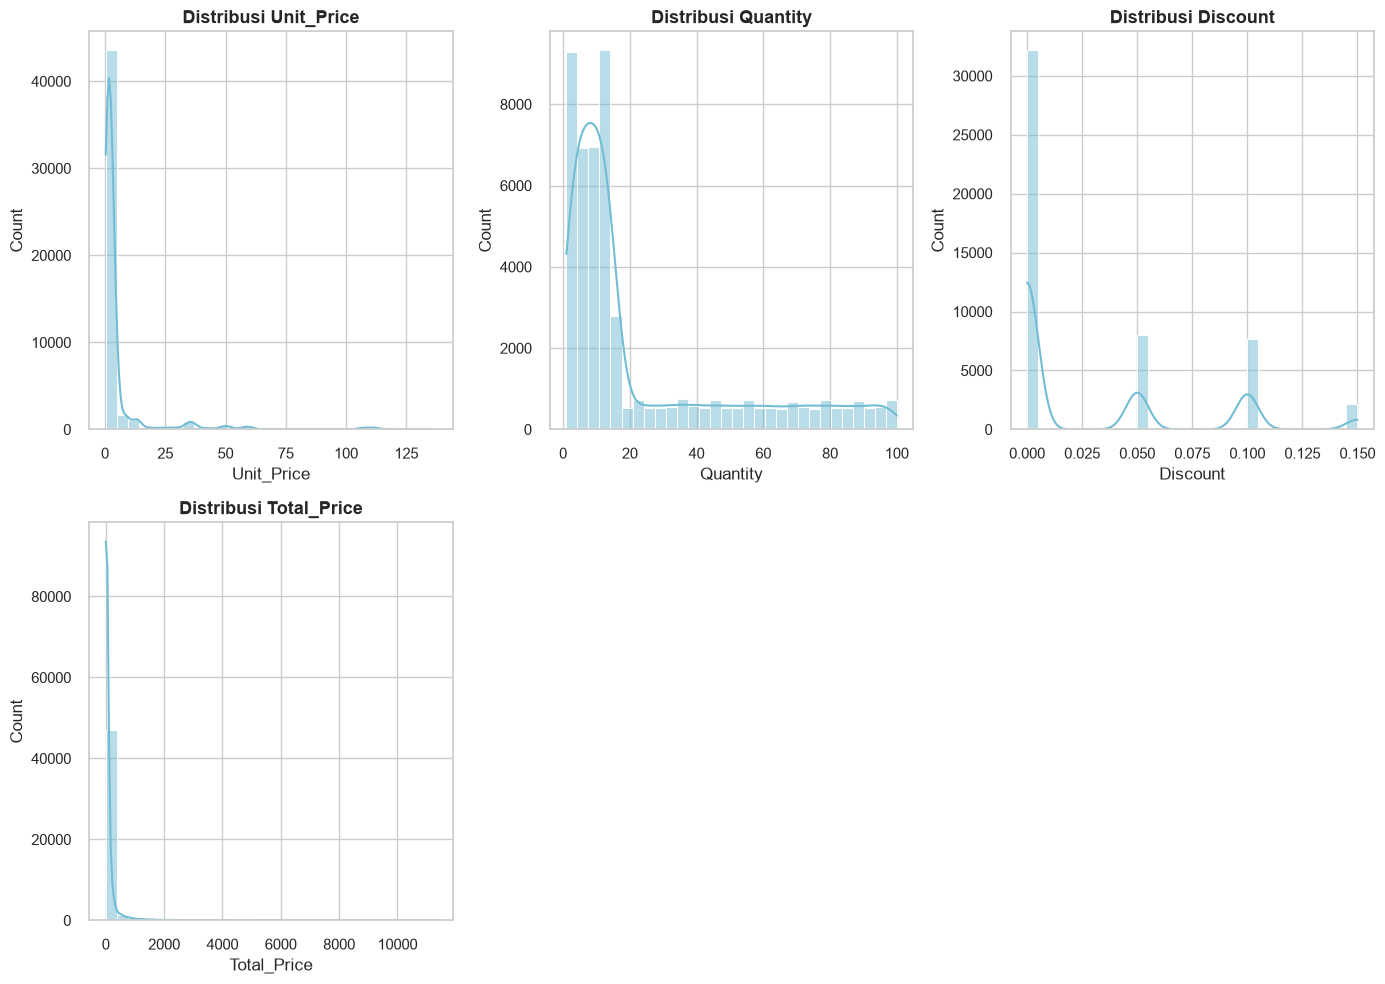

In [10]:
plt.figure(figsize=(14, 10))
for i, column in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[column], bins=30, kde=True, color=ACCENT_COLOR)
    plt.title(f"Distribusi {column}")
plt.tight_layout()
plt.show()

## 4.5 Korelasi Antar Variabel Numerik

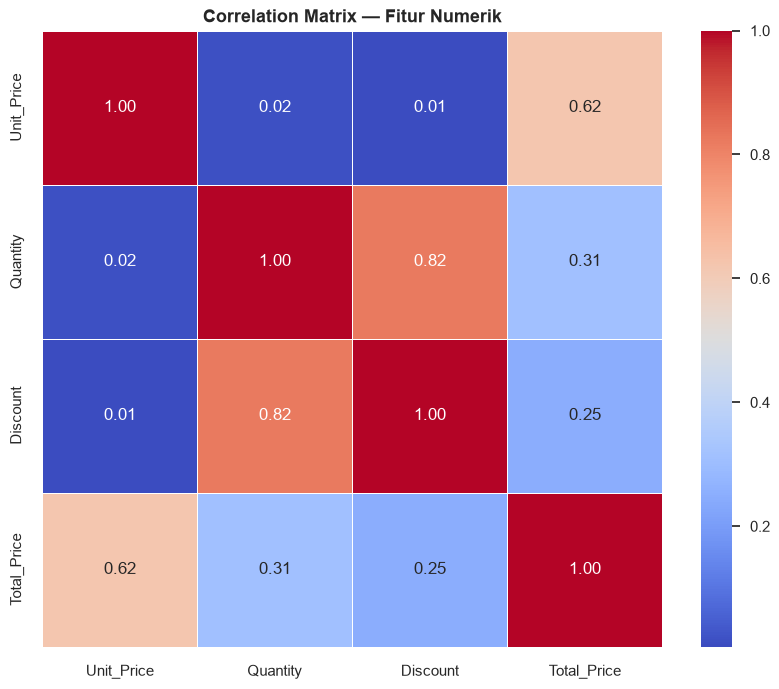

In [11]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — Fitur Numerik")
plt.show()

## 4.6 Analisis Variabel Kategorikal

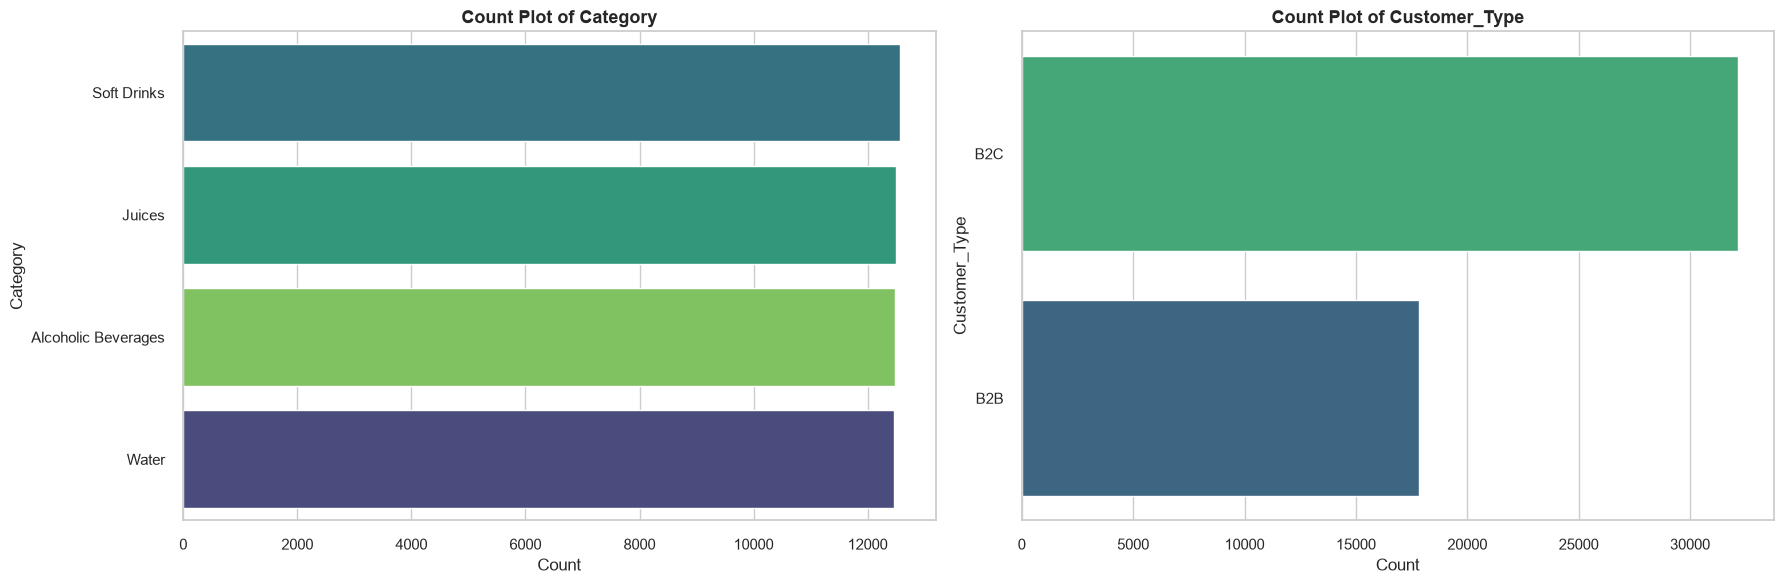

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribusi kategori produk
sns.countplot(y="Category", data=df, hue="Category", palette="viridis",
              order=df["Category"].value_counts().index, legend=False, ax=axes[0])
axes[0].set_title("Count Plot of Category")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

# Distribusi tipe pelanggan
sns.countplot(y="Customer_Type", data=df, hue="Customer_Type", palette="viridis",
              order=df["Customer_Type"].value_counts().index, legend=False, ax=axes[1])
axes[1].set_title("Count Plot of Customer_Type")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Customer_Type")

plt.tight_layout()
plt.show()

## 4.7 Analisis Berdasarkan Wilayah & Pelanggan

**Jumlah pelanggan unik per wilayah:**

In [13]:
df.groupby(by='Region').Customer_ID.nunique().sort_values(ascending=False)

Region
Hamburg                   570
Niedersachsen             521
Rheinland-Pfalz           521
Bremen                    520
Nordrhein-Westfalen       520
Baden-Württemberg         517
Schleswig-Holstein        513
Saarland                  507
Mecklenburg-Vorpommern    506
Sachsen                   505
Sachsen-Anhalt            505
Thüringen                 498
Bayern                    493
Hessen                    491
Brandenburg               488
Berlin                    482
Name: Customer_ID, dtype: int64

**Distribusi tipe pelanggan:**

In [14]:
df.Customer_Type.value_counts()

Customer_Type
B2C    32160
B2B    17840
Name: count, dtype: int64

**Distribusi produk:**

In [15]:
df.Product.value_counts()

Product
Mango Juice            1837
Hohes C Orange         1835
Tomato Juice           1801
Cranberry Juice        1775
Granini Apple          1756
Rauch Multivitamin     1747
Passion Fruit Juice    1745
Selters                1426
Volvic Touch           1419
San Pellegrino         1392
Vittel                 1391
Gerolsteiner           1384
Vio Wasser             1375
Apollinaris            1370
Volvic                 1356
Evian                  1348
Fritz-Kola             1301
Sprite                 1139
Coca-Cola              1120
Fanta                  1099
Red Bull               1029
Monster                1012
Club Mate              1012
Mountain Dew            990
Pepsi                   979
Mezzo Mix               964
Schwip Schwap           959
Rockstar                958
Beck's                  775
Rotkäppchen Sekt        730
Riesling                729
Kölsch                  680
Tanqueray               675
Krombacher              673
Jever                   661
Chardonnay  

**Jumlah order unik per wilayah:**

In [16]:
df.groupby(by='Region').Order_ID.nunique().sort_values(ascending=False).reset_index()

,Region,Order_ID
0,Hamburg,1125
1,Bremen,1111
2,Rheinland-Pfalz,1084
3,Baden-Württemberg,1083
4,Nordrhein-Westfalen,1065
5,Sachsen-Anhalt,1062
6,Mecklenburg-Vorpommern,1058
7,Niedersachsen,1046
8,Sachsen,1043
9,Thüringen,1040


## 4.8 Ringkasan Penjualan per Produk & Wilayah

In [17]:
df.groupby(by="Product").agg({
    "Quantity": "sum",
    "Total_Price": ["min", "max"]
})

Quantity Total_Price          
                         sum         min       max
Product                                           
Apollinaris            31954        0.44    140.94
Augustiner             14063        1.09    313.63
Bacardi                13466       13.44   3835.76
Beck's                 18233        1.00    213.01
Chardonnay             15334        3.66   1456.06
Club Mate              24143        1.80    233.96
Coca-Cola              25119        0.54    148.61
Cranberry Juice        41764        2.02    388.33
Erdinger Weißbier      15441        1.05    294.98
Evian                  32041        0.63    169.29
Fanta                  25520        0.58    150.30
Fritz-Kola             29031        1.99    304.20
Gerolsteiner           31328        0.42    141.42
Granini Apple          40294        1.24    253.94
Havana Club            14947       12.58   4099.50
Hohes C Orange         40954        1.14    300.96
Jack Daniels           12808       32.99   4717.30
Jever                  16104        1.36    199.75
Johnnie Walker         15657       27.53   5533.20
Krombacher             16391        1.54    189.61
Kölsch                 14934        0.93    232.55
Mango Juice            41068        2.03    396.48
Merlot                 15431        3.64   1351.76
Mezzo Mix              23050        0.59    155.23
Monster                23141        1.99    373.63
Mountain Dew           22702        0.54    153.47
Moët & Chandon         14812       42.03  11325.33
Passion Fruit Juice    40334        2.20    400.43
Pepsi                  22667        0.79    153.90
Rauch Multivitamin     38332        2.31    350.15
Red Bull               25340        2.17    358.80
Riesling               16099        3.52   1513.02
Rockstar               22519        1.71    364.04
Rotkäppchen Sekt       17004        3.28   1001.48
San Pellegrino         33551        0.40    148.95
Sauvignon Blanc        15388        4.44   1416.01
Schwip Schwap          22461        0.61    148.10
Selters                33260        0.40    144.49
Sprite                 27386        0.53    151.47
Tanqueray              14720       18.03   4523.73
Tomato Juice           42963        1.61    351.00
Veuve Clicquot         14000       32.86  10949.13
Vio Wasser             32178        0.53    192.04
Vittel                 31508        0.38    102.82
Volvic                 30507        0.55    102.14
Volvic Touch           32368        0.51    199.22
Warsteiner             13452        1.02    199.04

Ringkasan kuantitas dan total penjualan berdasarkan **wilayah & produk** (semua baris ditampilkan hanya pada cell ini menggunakan *context manager*, tanpa mengubah pengaturan tampilan global):

In [18]:
with pd.option_context("display.max_rows", None):
    display(
        df.groupby(by=["Region", "Product"]).agg({
            "Quantity": "sum",
            "Total_Price": "sum"
        })
    )

Quantity  Total_Price
Region                 Product                                   
Baden-Württemberg      Apollinaris              2099      1896.55
                       Augustiner                770      1429.93
                       Bacardi                  1207     28376.86
                       Beck's                    668       939.90
                       Chardonnay               1125      9570.96
                       Club Mate                1827      3655.36
                       Coca-Cola                2201      2332.38
                       Cranberry Juice          3174     10360.17
                       Erdinger Weißbier         855      1755.57
                       Evian                    2060      2330.05
                       Fanta                    1696      1816.88
                       Fritz-Kola               1411      3228.41
                       Gerolsteiner             1852      1677.82
                       Granini Apple            2421      3919.43
                       Havana Club               722     15103.52
                       Hohes C Orange           2413      4817.74
                       Jack Daniels             1016     35888.10
                       Jever                     881      1297.91
                       Johnnie Walker           1148     40881.05
                       Krombacher               1195      1695.52
                       Kölsch                   1254      1861.29
                       Mango Juice              2432      7579.38
                       Merlot                    967      7598.96
                       Mezzo Mix                1641      1549.81
                       Monster                  1766      4907.66
                       Mountain Dew             1355      1283.41
                       Moët & Chandon            987     69970.83
                       Passion Fruit Juice      2806      8829.26
                       Pepsi                    1353      1623.50
                       Rauch Multivitamin       2438      6117.65
                       Red Bull                 1329      3387.88
                       Riesling                  739      6280.13
                       Rockstar                 1278      3101.05
                       Rotkäppchen Sekt         1147      6920.28
                       San Pellegrino           2036      1869.58
                       Sauvignon Blanc          1178      9852.76
                       Schwip Schwap            1384      1436.67
                       Selters                  1743      1220.71
                       Sprite                   2140      2070.27
                       Tanqueray                 861     26128.48
                       Tomato Juice             3674      9954.28
                       Veuve Clicquot            945     68672.18
                       Vio Wasser               1738      2366.31
                       Vittel                   2028      1368.93
                       Volvic                   1452       864.92
                       Volvic Touch             2156      2702.60
                       Warsteiner               1093      1401.59
Bayern                 Apollinaris              2334      2014.28
                       Augustiner                590       836.91
                       Bacardi                   459      9595.69
                       Beck's                    904      1271.95
                       Chardonnay                958      7084.54
                       Club Mate                1429      2790.33
                       Coca-Cola                1361      1400.70
                       Cranberry Juice          2512      8008.39
                       Erdinger Weißbier        1283      2530.08
                       Evian                    1544      1707.98
                       Fanta                    1885      1968.32
                       Fritz-Kola               1196      2636.06
                  

Ringkasan kuantitas dan total penjualan berdasarkan **tipe pelanggan & produk**:

In [19]:
df.groupby(by=["Customer_Type", "Product"]).agg({
    "Quantity": "sum",
    "Total_Price": "sum"
})

Quantity  Total_Price
Customer_Type Product                            
B2B           Apollinaris      24825     21310.94
              Augustiner       10728     20952.77
              Bacardi          10466    256741.75
              Beck's           14126     20177.69
              Chardonnay       12036    106157.99
...                              ...          ...
B2C           Vio Wasser        7184     11908.29
              Vittel            7482      4427.63
              Volvic            7226      4095.03
              Volvic Touch      7331     10416.34
              Warsteiner        3144      3304.98

[94 rows x 2 columns]

## 4.9 Produk Terlaris & Kurang Laris

In [20]:
sum_order_items_df = (
    df.groupby("Product").Quantity.sum()
    .sort_values(ascending=False)
    .reset_index()
)
sum_order_items_df.head(15)

,Product,Quantity
0,Tomato Juice,42963
1,Cranberry Juice,41764
2,Mango Juice,41068
3,Hohes C Orange,40954
4,Passion Fruit Juice,40334
5,Granini Apple,40294
6,Rauch Multivitamin,38332
7,San Pellegrino,33551
8,Selters,33260
9,Volvic Touch,32368


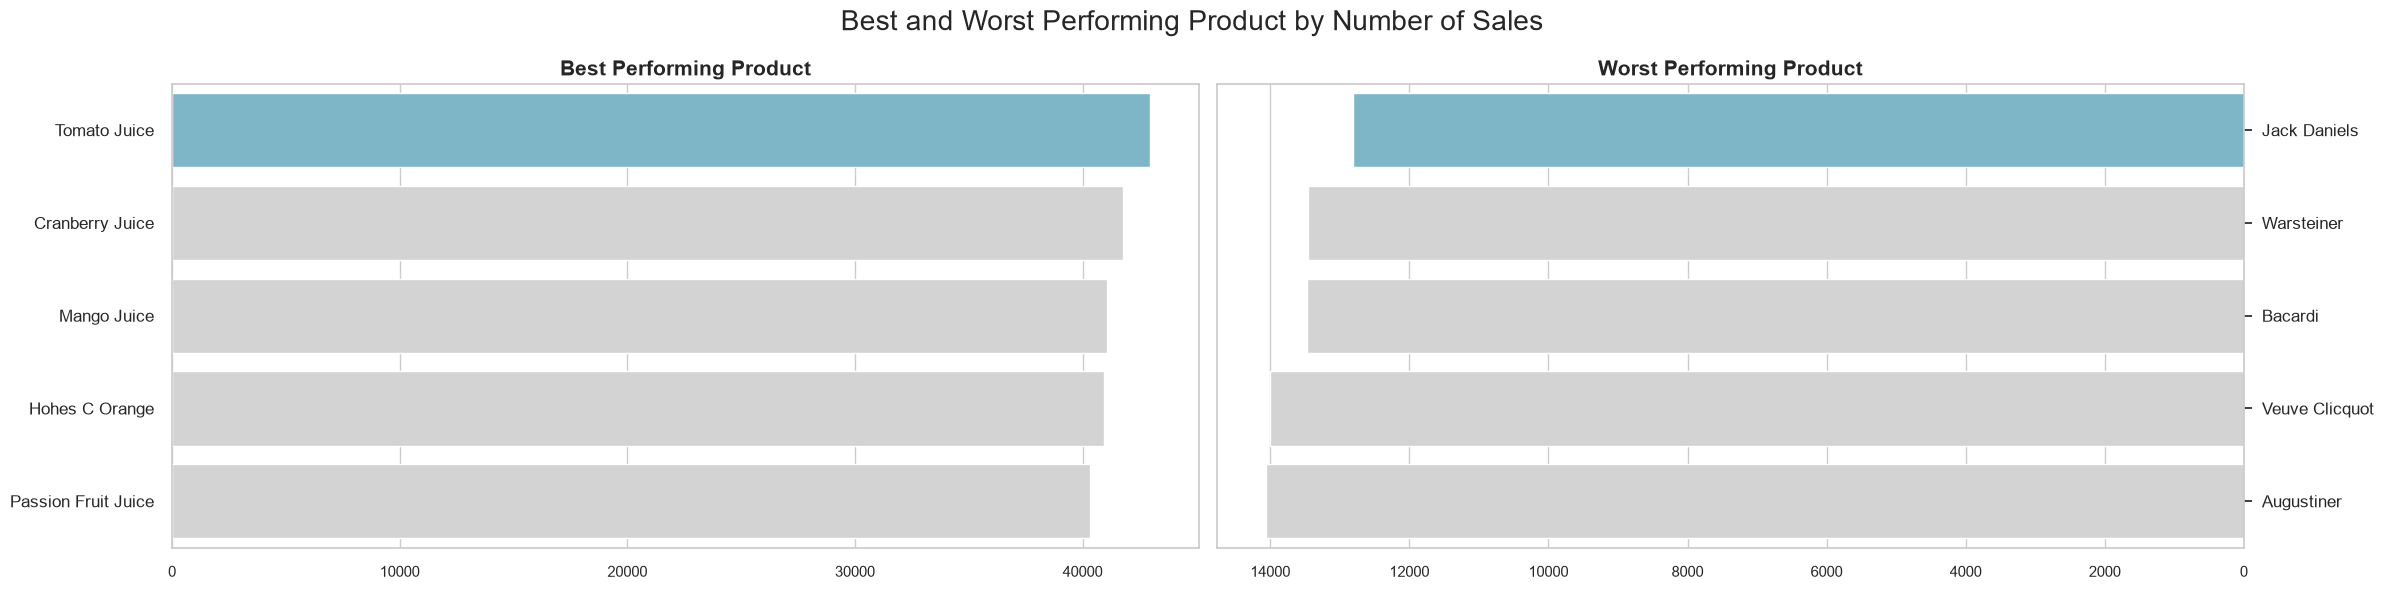

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = [ACCENT_COLOR, MUTED_COLOR, MUTED_COLOR, MUTED_COLOR, MUTED_COLOR]

# --- Produk dengan penjualan (kuantitas) tertinggi ---
top5 = sum_order_items_df.head(5)
sns.barplot(x="Quantity", y="Product", data=top5, hue="Product",
            palette=colors, legend=False, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=15)
ax[0].tick_params(axis="y", labelsize=12)

# --- Produk dengan penjualan (kuantitas) terendah ---
bottom5 = sum_order_items_df.sort_values(by="Quantity", ascending=True).head(5)
sns.barplot(x="Quantity", y="Product", data=bottom5, hue="Product",
            palette=colors, legend=False, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=15)
ax[1].tick_params(axis="y", labelsize=12)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.tight_layout()
plt.show()

## 4.10 Tren Penjualan Bulanan

Kolom tanggal dikonversi ke tipe `datetime` agar dapat digunakan untuk analisis tren waktu (*resampling* bulanan).

In [22]:
datetime_columns = ["Order_Date"]

for column in datetime_columns:
    df[column] = pd.to_datetime(df[column])

In [23]:
monthly_orders_df = df.resample(rule="M", on="Order_Date").agg({
    "Order_ID": "nunique",
    "Total_Price": "sum"
})
monthly_orders_df.index = monthly_orders_df.index.strftime("%Y-%m")
monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "Order_ID": "Order_Count",
    "Total_Price": "Revenue"
}, inplace=True)

monthly_orders_df

C:\Users\abiyy\AppData\Local\Temp\ipykernel_17380\1879010610.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = df.resample(rule="M", on="Order_Date").agg({


,Order_Date,Order_Count,Revenue
0,2021-01,488,179004.50
1,2021-02,408,183744.71
2,2021-03,492,171491.60
3,2021-04,456,149649.35
4,2021-05,449,136478.99
5,2021-06,442,161486.33
6,2021-07,454,148827.63
7,2021-08,484,180094.60
8,2021-09,450,150658.85
9,2021-10,453,198937.91


## 4.11 Jumlah Pelanggan per Wilayah

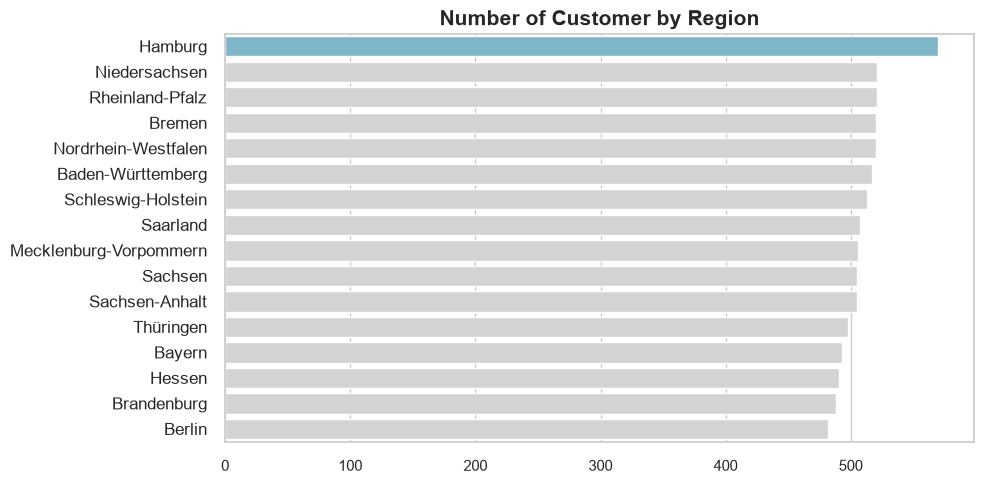

In [24]:
byregion_df = df.groupby(by="Region").Customer_ID.nunique().reset_index()
byregion_df.rename(columns={"Customer_ID": "Customer_Count"}, inplace=True)
byregion_df = byregion_df.sort_values(by="Customer_Count", ascending=False)

plt.figure(figsize=(10, 5))
colors_ = [ACCENT_COLOR] + [MUTED_COLOR] * (len(byregion_df) - 1)
sns.barplot(x="Customer_Count", y="Region", data=byregion_df, hue="Region",
            palette=colors_, legend=False)
plt.title("Number of Customer by Region", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis="y", labelsize=12)
plt.tight_layout()
plt.show()

## 4.12 Analisis Multivariat (Pairplot)

> ⏳ Proses ini bisa memakan waktu cukup lama tergantung jumlah baris & kolom numerik pada dataset.

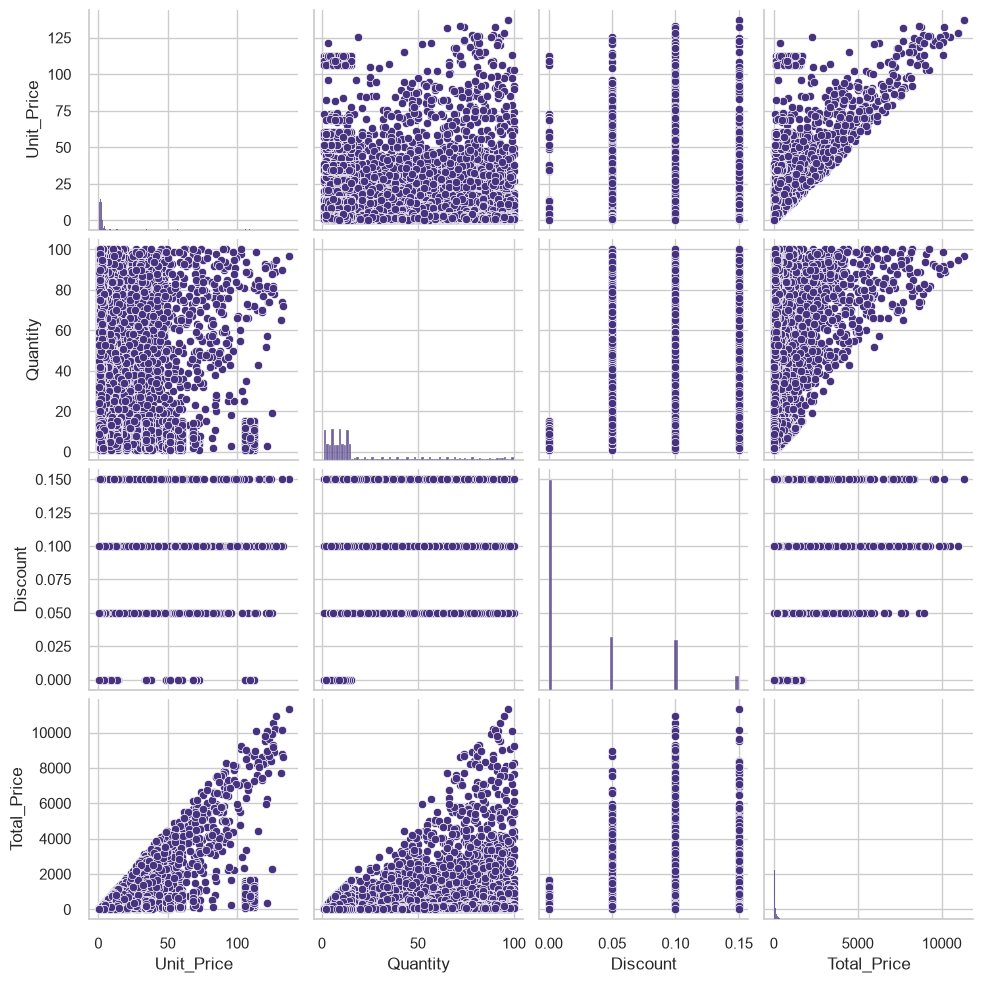

In [25]:
sns.pairplot(df)
plt.show()

<a id="section-5"></a>
# 5. 🧹 Data Preprocessing

Data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model *machine learning*. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau menangani data kosong (*missing values*)
2. Menghapus data duplikat
3. Normalisasi atau standarisasi fitur
4. Deteksi dan penanganan outlier
5. Encoding data kategorikal
6. Binning (pengelompokan data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan ya.

## 5.1 Penanganan Outlier (Metode IQR)

In [26]:
X_cleaned = df.copy()

# Hitung batas bawah & atas menggunakan metode IQR (Interquartile Range)
Q1 = X_cleaned[int_float_features].quantile(0.25)
Q3 = X_cleaned[int_float_features].quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (X_cleaned[int_float_features] < (Q1 - 1.5 * IQR)) |
    (X_cleaned[int_float_features] > (Q3 + 1.5 * IQR))
).any(axis=1)

print("Jumlah Outlier Teridentifikasi   :", outliers.sum())

# Menghapus baris yang teridentifikasi sebagai outlier
X_cleaned = X_cleaned.loc[~outliers]
print("Jumlah Baris Setelah Menghapus Outlier:", X_cleaned.shape[0])

Jumlah Outlier Teridentifikasi   : 12177
Jumlah Baris Setelah Menghapus Outlier: 37823


## 5.2 Menghapus Kolom Identitas

`Order_ID` dan `Customer_ID` merupakan kolom identitas (bukan fitur informatif untuk clustering) sehingga dihapus dari dataset.

In [27]:
X_cleaned = X_cleaned.drop(["Order_ID", "Customer_ID"], axis=1)
X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
4,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
6,B2B,Tomato Juice,Juices,2.14,44,0.10,84.74,Hamburg,2022-11-20
7,B2B,Vittel,Water,0.43,13,0.05,5.31,Hamburg,2022-11-20
9,B2B,Evian,Water,1.38,3,0.05,3.93,Hamburg,2022-11-20


## 5.3 Standarisasi Fitur Numerik

Fitur numerik distandarisasi menggunakan `StandardScaler` agar memiliki skala yang setara (mean = 0, std = 1), sehingga tidak ada fitur yang mendominasi perhitungan jarak pada K-Means.

In [28]:
scaler = StandardScaler()
X_cleaned[int_float_features] = scaler.fit_transform(X_cleaned[int_float_features])

print("Data Numerikal Setelah Normalisasi/Standarisasi:")
X_cleaned[int_float_features].head()

Data Numerikal Setelah Normalisasi/Standarisasi:


,Unit_Price,Quantity,Discount,Total_Price
0,-0.124207,2.735597,2.667548,2.212742
4,-0.873491,1.475886,2.667548,0.187121
6,0.331055,2.105741,2.667548,2.430248
7,-1.290814,-0.063761,1.068102,-0.677035
9,-0.389776,-0.763601,1.068102,-0.731020


## 5.4 Encoding Fitur Kategorikal

Setiap fitur kategorikal diubah menjadi representasi numerik menggunakan `LabelEncoder`. Encoder untuk masing-masing kolom disimpan agar dapat digunakan untuk *inverse transform* (mengembalikan ke nilai asli) pada tahap interpretasi cluster.

In [29]:
label_encoders = {}

# Menghapus 'Order_ID' dan 'Customer_ID' dari daftar categorical_features jika masih ada
categorical_features = [col for col in categorical_features if col not in ["Order_ID", "Customer_ID"]]

for col in categorical_features:
    le = LabelEncoder()
    X_cleaned.loc[:, col] = le.fit_transform(X_cleaned[col])
    label_encoders[col] = le  # simpan encoder untuk interpretasi nanti

print("Data Kategorikal Setelah Encoding:")
X_cleaned[categorical_features].head()

Data Kategorikal Setelah Encoding:


C:\Users\abiyy\AppData\Local\Temp\ipykernel_17380\3550645824.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[964 964 688 ... 895 131 131]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  X_cleaned.loc[:, col] = le.fit_transform(X_cleaned[col])


,Customer_Type,Product,Category,Region,Order_Date
0,0,35,3,0,964
4,0,11,3,0,964
6,0,34,1,5,688
7,0,36,3,5,688
9,0,8,3,5,688


Cek 5 baris terakhir hasil encoding:

In [30]:
X_cleaned[categorical_features].tail()

,Customer_Type,Product,Category,Region,Order_Date
49995,1,6,1,6,895
49996,1,22,1,6,895
49997,1,0,3,6,895
49998,1,26,0,10,131
49999,1,32,3,10,131


<a id="section-6"></a>
# 6. 🤖 Pembangunan Model Clustering

<a id="section-6a"></a>
## 6a. 🏗️ Pembangunan Model Clustering

Pada tahap ini, kita membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

Algoritma yang digunakan di sini adalah **K-Means**, dengan jumlah cluster awal ditentukan melalui **Elbow Method** (divisualisasikan menggunakan `KElbowVisualizer`).

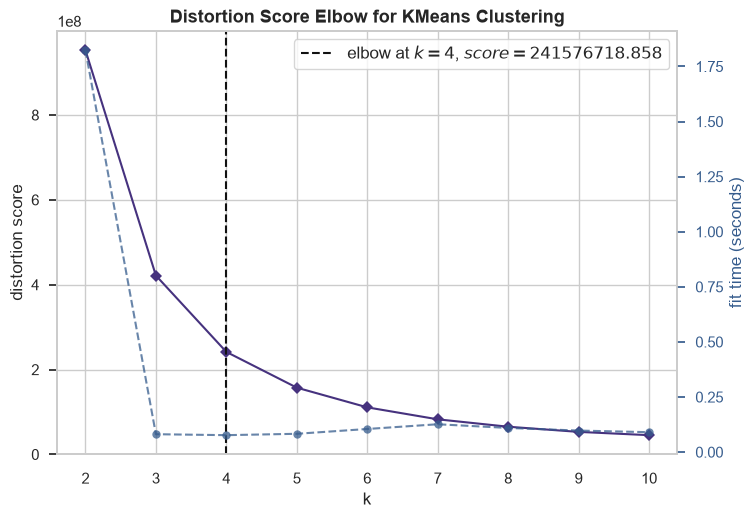

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [33]:
# Inisialisasi model KMeans
kmeans = KMeans(random_state=42)

# Gunakan force_model=True untuk membypass pengecekan tipe model
visualizer = KElbowVisualizer(kmeans, k=(2, 11), force_model=True)

# Fit visualizer
visualizer.fit(X_cleaned)

# Tampilkan visualisasi
visualizer.show()

In [34]:
# Pilih jumlah cluster awal (misalnya, 2) berdasarkan hasil Elbow Method di atas
n_clusters = 2

# Latih model clustering awal
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

<a id="section-6b"></a>
## 6b. 📈 Evaluasi Model Clustering

Untuk menentukan jumlah cluster yang optimal dalam model clustering, kita dapat menggunakan metode **Elbow** atau **Silhouette Score**.

Metode ini membantu menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

Jumlah klaster: 2, Silhouette Score: 0.6203 - Disimpan
Jumlah klaster: 3, Silhouette Score: 0.5847 - Disimpan


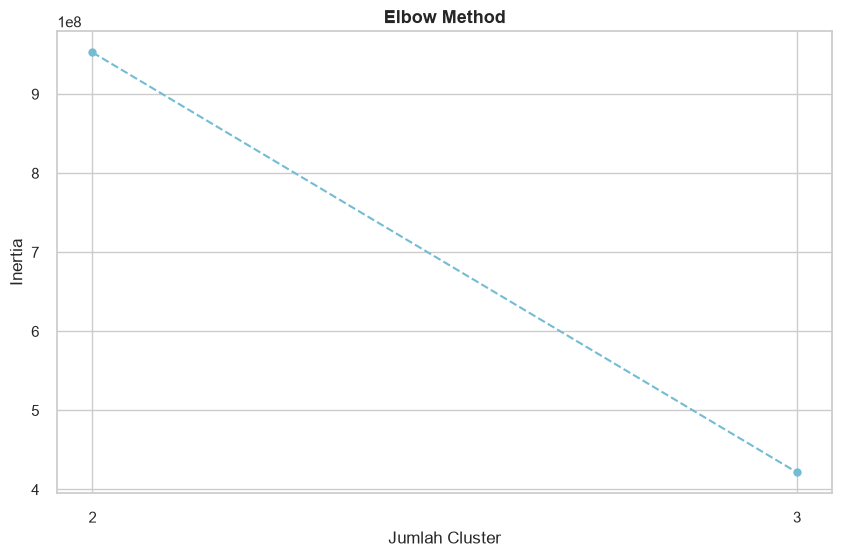

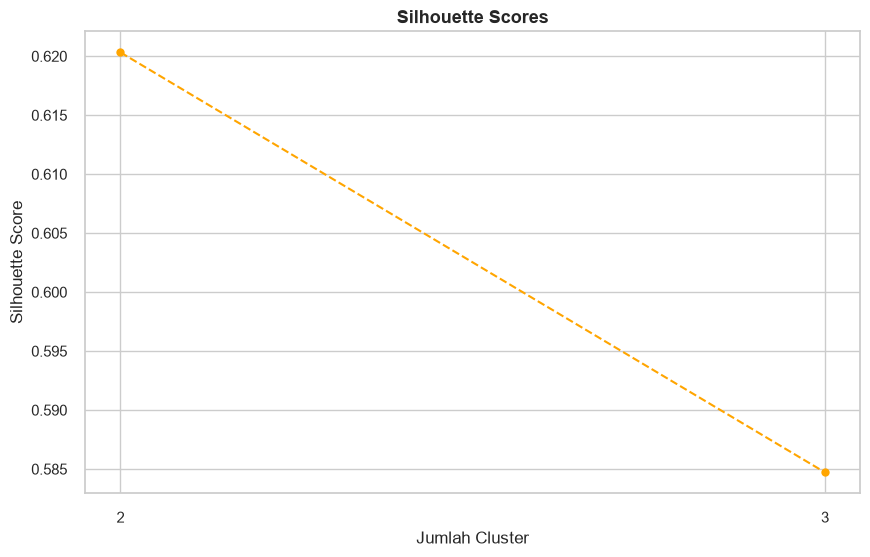


Jumlah cluster optimal berdasarkan Silhouette Score: 2


In [35]:
# Rentang jumlah cluster yang akan diuji
range_n_clusters = range(2, 4)
SILHOUETTE_THRESHOLD = 0.55

inertia = []
silhouette_scores = []
valid_cluster_labels = []  # menyimpan label klaster yang memenuhi threshold

for n_clusters in range_n_clusters:
    # Melakukan klasterisasi KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_cleaned)

    # Hitung Silhouette Score & simpan inertia (SSE) untuk Elbow Method
    silhouette_avg = silhouette_score(X_cleaned, cluster_labels)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_avg)

    if silhouette_avg >= SILHOUETTE_THRESHOLD:
        valid_cluster_labels.append(cluster_labels)
        print(f"Jumlah klaster: {n_clusters}, Silhouette Score: {silhouette_avg:.4f} - Disimpan")
    else:
        print(f"Jumlah klaster: {n_clusters}, Silhouette Score: {silhouette_avg:.4f} - Tidak Disimpan")

# --- Plot Elbow Method ---
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker="o", linestyle="--", color=ACCENT_COLOR)
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.xticks(range_n_clusters)
plt.show()

# --- Plot Silhouette Score ---
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker="o", linestyle="--", color="orange")
plt.title("Silhouette Scores")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.xticks(range_n_clusters)
plt.show()

# Pilih jumlah cluster optimal berdasarkan Silhouette Score tertinggi
optimal_n_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 karena range dimulai dari 2
print(f"\nJumlah cluster optimal berdasarkan Silhouette Score: {optimal_n_clusters}")

In [36]:
# Latih model final dengan jumlah cluster optimal, lalu simpan label cluster ke dataset
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)
X_cleaned["Cluster"] = kmeans.fit_predict(X_cleaned)

X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,0,35,3,-0.124207,2.735597,2.667548,2.212742,0,964,1
4,0,11,3,-0.873491,1.475886,2.667548,0.187121,0,964,1
6,0,34,1,0.331055,2.105741,2.667548,2.430248,5,688,1
7,0,36,3,-1.290814,-0.063761,1.068102,-0.677035,5,688,1
9,0,8,3,-0.389776,-0.763601,1.068102,-0.731020,5,688,1


<a id="section-6c"></a>
## 6c. 🎯 Feature Selection (Opsional)

Silakan lakukan *feature selection* jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil *feature selection*. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan *feature selection*.

> ℹ️ Bagian ini bersifat opsional — dapat dilewati jika tidak diperlukan untuk kasus Anda.

<a id="section-6d"></a>
## 6d. 🖼️ Visualisasi Hasil Clustering

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti scatter plot atau 2D PCA projection.

In [37]:
X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,0,35,3,-0.124207,2.735597,2.667548,2.212742,0,964,1
4,0,11,3,-0.873491,1.475886,2.667548,0.187121,0,964,1
6,0,34,1,0.331055,2.105741,2.667548,2.430248,5,688,1
7,0,36,3,-1.290814,-0.063761,1.068102,-0.677035,5,688,1
9,0,8,3,-0.389776,-0.763601,1.068102,-0.731020,5,688,1


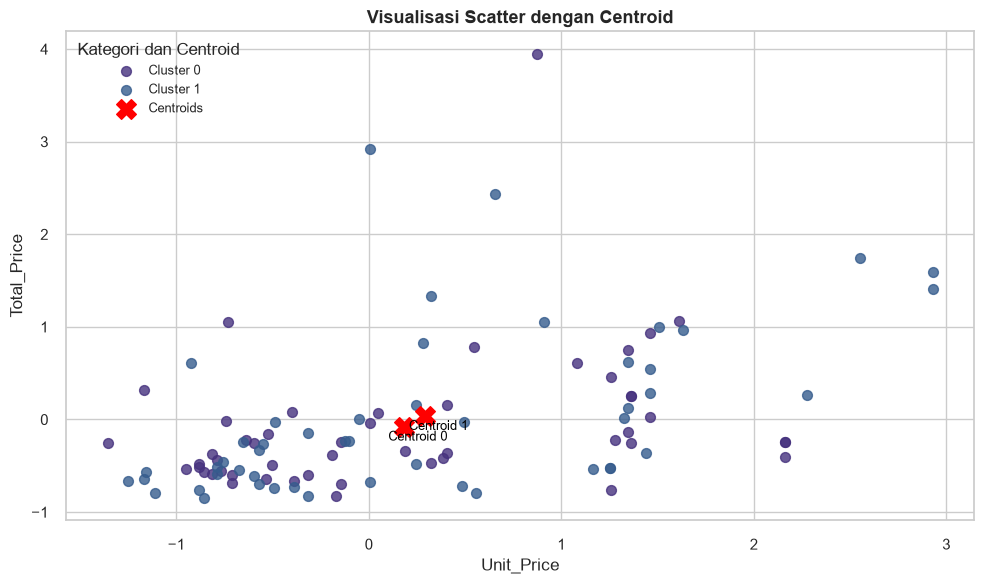

In [38]:
# Mengambil sampel data secara acak agar scatter plot lebih mudah dibaca
sampled_data = X_cleaned.sample(n=100, random_state=42)

# Pilih kolom untuk sumbu X dan Y
x_column = "Unit_Price"   # ganti dengan nama kolom yang diinginkan untuk sumbu X
y_column = "Total_Price"  # ganti dengan nama kolom yang diinginkan untuk sumbu Y

# Menghitung centroid (rata-rata x & y) untuk setiap cluster pada sampel data
centroids = sampled_data.groupby("Cluster")[[x_column, y_column]].mean()

# --- Visualisasi scatter plot ---
plt.figure(figsize=(10, 6))

# Plot titik data per cluster
for cluster_label in sorted(sampled_data["Cluster"].unique()):
    cluster_data = sampled_data[sampled_data["Cluster"] == cluster_label]
    plt.scatter(
        cluster_data[x_column],
        cluster_data[y_column],
        label=f"Cluster {cluster_label}",
        s=50,
        alpha=0.8
    )

# Tambahkan centroid ke plot
plt.scatter(
    centroids[x_column],
    centroids[y_column],
    color="red",
    s=200,
    marker="X",
    label="Centroids"
)

# Anotasi centroid
for cluster_label, coord in centroids.iterrows():
    plt.annotate(
        f"Centroid {cluster_label}",
        (coord[x_column], coord[y_column]),
        textcoords="offset points",
        xytext=(10, -10),
        ha="center",
        fontsize=9,
        color="black"
    )

plt.title("Visualisasi Scatter dengan Centroid")
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend(title="Kategori dan Centroid", loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

<a id="section-6e"></a>
## 6e. 🧠 Analisis dan Interpretasi Hasil Cluster

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya agar hasil cluster lebih mudah diinterpretasikan. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan hasil label cluster ke DataFrame**

Setelah mendapatkan hasil clustering, tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi:

```python
df_normalized["Cluster"] = model_kmeans.labels_
```

**2. Inverse transform untuk fitur kategorikal (hasil Label Encoding)**

```python
label_encoder.inverse_transform(X_Selected[["Fitur"]])
```

Lalu masukkan hasilnya ke dalam kolom dataset asli atau buat DataFrame baru:

```python
df_normalized["Fitur"] = label_encoder.inverse_transform(df_normalized[["Fitur"]])
```

**3. Masukkan data yang sudah di-*inverse*** ke dalam dataset asli (atau buat DataFrame baru):

```python
df_original["Fitur"] = df_normalized["Fitur"]
```

In [39]:
# Inverse transform untuk fitur kategorikal (mengembalikan hasil Label Encoding ke nilai asli)
for col in categorical_features:
    le = label_encoders[col]
    # Pastikan tipe data integer sebelum inverse_transform
    X_cleaned.loc[:, col] = le.inverse_transform(X_cleaned[col].astype(int))

C:\Users\abiyy\AppData\Local\Temp\ipykernel_17380\706624831.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2023-08-23T00:00:00.000000000' '2023-08-23T00:00:00.000000000'
 '2022-11-20T00:00:00.000000000' ... '2023-06-15T00:00:00.000000000'
 '2021-05-12T00:00:00.000000000' '2021-05-12T00:00:00.000000000']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_cleaned.loc[:, col] = le.inverse_transform(X_cleaned[col].astype(int))


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Jika data numerik telah dinormalisasi menggunakan `StandardScaler` atau `MinMaxScaler`, kita bisa mengembalikannya ke skala asli:

```python
df_normalized[["Fitur_Numerik"]] = scaler.inverse_transform(df_normalized[["Fitur_Numerik"]])
```

In [40]:
# Inverse transform untuk fitur numerik (mengembalikan hasil StandardScaler ke skala asli)
X_cleaned[int_float_features] = scaler.inverse_transform(X_cleaned[int_float_features])

In [41]:
X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,B2B,Vio Wasser,Water,1.66,53.0,0.10,79.18,Baden-Württemberg,2023-08-23,1
4,B2B,Gerolsteiner,Water,0.87,35.0,0.10,27.40,Baden-Württemberg,2023-08-23,1
6,B2B,Tomato Juice,Juices,2.14,44.0,0.10,84.74,Hamburg,2022-11-20,1
7,B2B,Vittel,Water,0.43,13.0,0.05,5.31,Hamburg,2022-11-20,1
9,B2B,Evian,Water,1.38,3.0,0.05,3.93,Hamburg,2022-11-20,1


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [42]:
# df["Cluster"] adalah kolom yang berisi label cluster hasil KMeans

# Statistik deskriptif (mean, median, std) untuk kolom numerik pada tiap cluster
cluster_summary = X_cleaned.groupby("Cluster")[int_float_features].agg(["mean", "median", "std"])
print(cluster_summary)

# Nilai modus (paling sering muncul) untuk tiap fitur kategorikal pada setiap cluster
cat_summary = X_cleaned.groupby("Cluster")[categorical_features].agg(lambda x: x.mode().iloc[0])
print(cat_summary)

        Unit_Price                    Quantity                    Discount  \
              mean median       std       mean median        std      mean   
Cluster                                                                      
0         1.757901   1.54  1.039483  13.799228   10.0  14.190244  0.016253   
1         1.823137   1.63  1.067675  14.019984   10.0  14.384378  0.016958   

                         Total_Price                    
        median       std        mean median        std  
Cluster                                                 
0          0.0  0.030965   22.045308  13.68  25.027825  
1          0.0  0.031544   23.173020  14.31  26.061824  
        Customer_Type             Product     Category   Region Order_Date
Cluster                                                                   
0                 B2C      Hohes C Orange        Water  Sachsen 2021-06-16
1                 B2C  Rauch Multivitamin  Soft Drinks  Hamburg 2023-10-15


**Distribusi nilai numerik dalam setiap cluster** (boxplot per fitur):

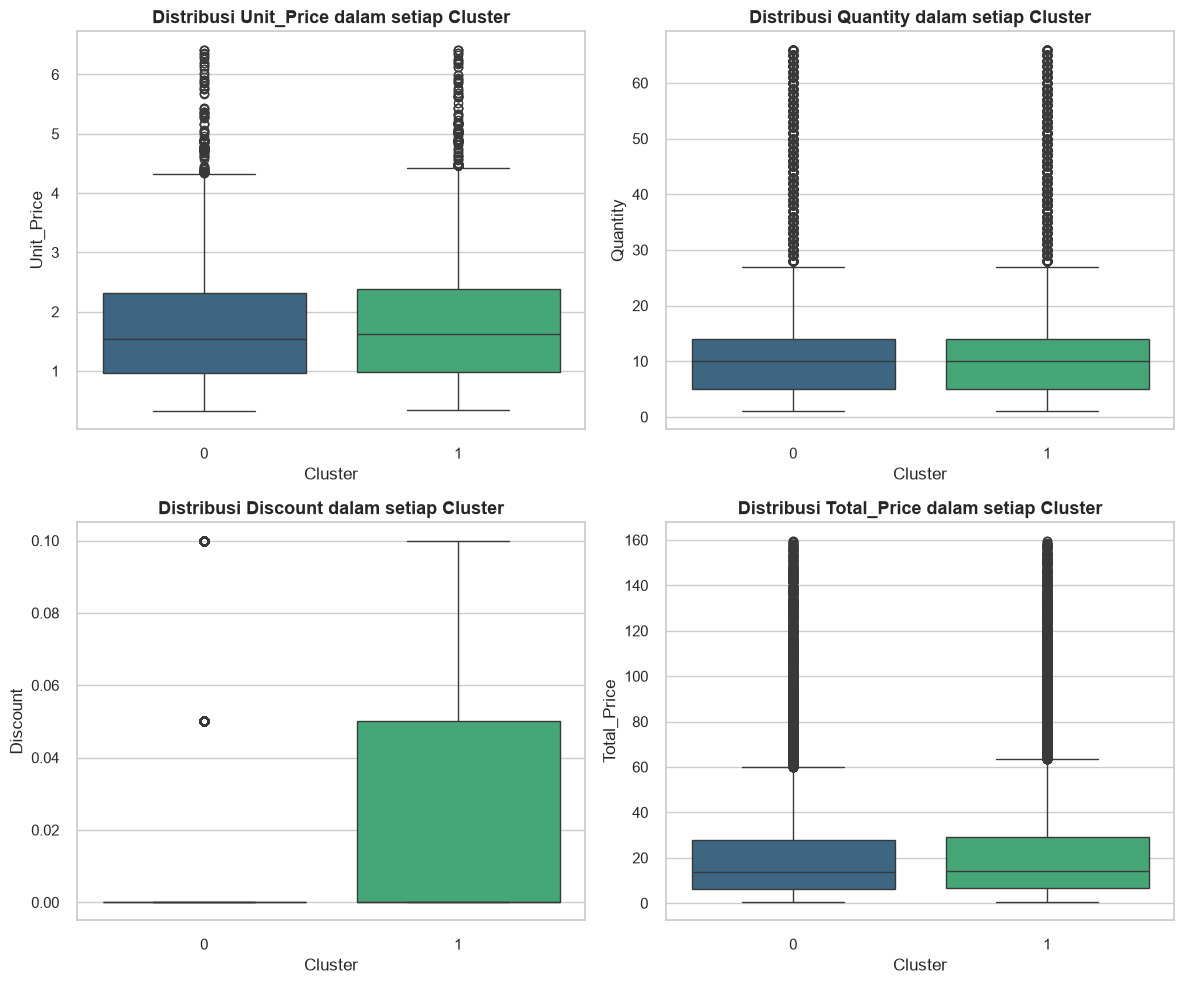

In [43]:
feature_cols = [col for col in int_float_features if col != "Cluster"]
n_cols = 2
n_rows = -(-len(feature_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(x="Cluster", y=col, data=X_cleaned, hue="Cluster", palette="viridis",
                legend=False, ax=axes[i])
    axes[i].set_title(f"Distribusi {col} dalam setiap Cluster")

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Scatter plot dua fitur pertama**, diwarnai berdasarkan cluster:

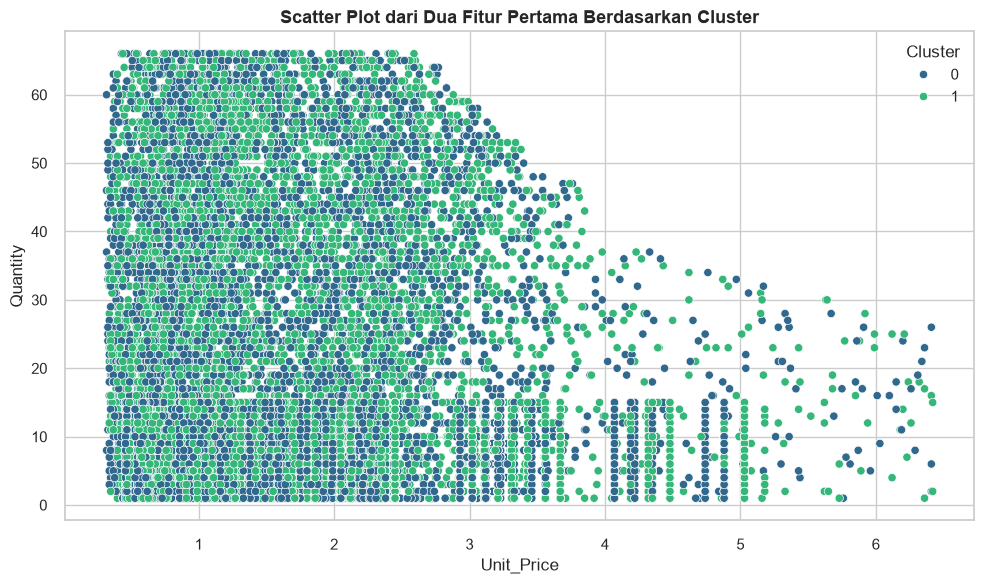

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=int_float_features[0],
    y=int_float_features[1],
    hue="Cluster",
    data=X_cleaned,
    palette="viridis"
)
plt.title("Scatter Plot dari Dua Fitur Pertama Berdasarkan Cluster")
plt.tight_layout()
plt.show()

### 📋 Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

#### Cluster 0

| Metrik | Nilai |
|---|---|
| Mean Unit Price | 1.757901 |
| Mean Quantity | 13.799228 |
| Mean Unit Discount | 0.016253 |
| Mean Total Price | 22.027825 |

**Karakteristik pelanggan:**
- **Customer Type:** B2C (Business to Customer)
- **Product:** Hohes C Orange
- **Category:** Water
- **Region:** Sachsen

**Analisis:** Cluster 0 terdiri dari pelanggan dengan rata-rata harga satuan sebesar 1.757901, yang sedikit lebih rendah dibandingkan cluster lain. Median harga satuan adalah 1.54 dengan penyimpangan sebesar 1.039483, menunjukkan adanya variasi harga dalam kelompok ini. Pelanggan rata-rata membeli 13.799228 produk dengan median sebanyak 10 dan penyimpangan sebanyak 14.190244, menandakan adanya fluktuasi dalam jumlah pembelian. Diskon rata-rata yang diberikan kecil, yaitu 0.016253, dengan median 0.0. Total pembelian rata-rata mencapai 22.045308 dengan median 13.68 dan penyimpangan sebesar 25.027825. Pelanggan dalam cluster ini kebanyakan berasal dari wilayah Sachsen dan termasuk dalam tipe pelanggan B2C. Produk yang paling dominan adalah Hohes C Orange dalam kategori Water, dengan tanggal pembelian yang banyak terjadi pada 16 Juni 2021. Pola ini menunjukkan bahwa pelanggan di cluster ini cenderung membeli produk dalam jumlah moderat untuk kebutuhan individu.

---

#### Cluster 1

| Metrik | Nilai |
|---|---|
| Mean Unit Price | 1.823137 |
| Mean Quantity | 14.019984 |
| Mean Unit Discount | 0.016958 |
| Mean Total Price | 23.173020 |

**Karakteristik pelanggan:**
- **Customer Type:** B2C (Business to Customer)
- **Product:** Rauch Multivitamin
- **Category:** Soft Drinks
- **Region:** Hamburg

**Analisis:** Cluster 1 terdiri dari pelanggan dengan rata-rata harga satuan sebesar 1.823137, sedikit lebih tinggi dari Cluster 0. Median harga satuan adalah 1.63 dengan penyimpangan sebesar 1.067675, menandakan adanya variasi harga dalam cluster ini. Jumlah rata-rata produk yang dibeli adalah 14.019984 dengan median sebanyak 10 dan penyimpangan sebesar 14.384378, menunjukkan pola pembelian yang stabil dengan beberapa fluktuasi. Diskon rata-rata yang diberikan sebesar 0.016958, dengan median 0.0. Total pembelian rata-rata mencapai 23.173020 dengan median 14.31 dan penyimpangan sebesar 26.061824. Pelanggan dalam cluster ini juga termasuk tipe B2C dan dominan membeli produk Rauch Multivitamin dalam kategori Soft Drinks. Sebagian besar pelanggan berasal dari wilayah Hamburg dan banyak melakukan pembelian pada 15 Oktober 2023. Cluster ini menggambarkan pelanggan dengan pola pembelian yang mirip dengan Cluster 0 tetapi memiliki preferensi terhadap produk kategori Soft Drinks.

<a id="section-7"></a>
# 7. 💾 Mengeksport Data

Simpan hasil akhir (dataset beserta label cluster) ke dalam file CSV.

In [ ]:
# Simpan dataset hasil clustering ke dalam file CSV
output_file = "hasil_clustering.csv"
X_cleaned.to_csv(output_file, index=False)

print(f"Dataset hasil clustering berhasil disimpan ke '{output_file}'")

---

## ✅ Ringkasan Alur Kerja

| Tahap | Deskripsi |
|---|---|
| 1️⃣ Perkenalan Dataset | Menentukan dan memvalidasi dataset tanpa label |
| 2️⃣ Import Library | Menyiapkan seluruh *tools* yang dibutuhkan |
| 3️⃣ Memuat Dataset | Membaca data ke dalam DataFrame |
| 4️⃣ EDA | Memahami struktur, distribusi, dan pola data |
| 5️⃣ Preprocessing | Menangani outlier, scaling, dan encoding |
| 6️⃣ Modeling | Membangun, mengevaluasi, memvisualisasikan, dan menginterpretasikan model K-Means |
| 7️⃣ Export | Menyimpan hasil akhir ke CSV |

*Notebook ini dapat dijalankan ulang secara end-to-end kapan pun dataset diperbarui.*